In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))
from paths import PROCESSED, RESULTS, savefig
from pypsa_helpers import (
    require_optimal,
    cost_by_technology,
    capacity_by_technology,
    generation_by_technology,
    electricity_mix,
    co2_shadow_price,
    total_co2,
    curtailment_rate,
    electricity_buses,
)

import pypsa
import pandas as pd
import matplotlib.pyplot as plt

Scenario Comparison: No CO2 Limit vs. 100% CO2 Reduction

A different comparison axis from `10_sensitivity_results_analysis.ipynb`: here electrolysis
cost is held at its baseline (100%) throughout, and instead the CO2 constraint itself is
varied - the two original mandatory scenarios from `07_scenario_no_co2_limit.ipynb` and
`08_scenario_100pct_co2_reduction.ipynb`.

Note: the CO2 shadow price only exists for the 100%-reduction case, since the no-CO2-limit
scenario has no CO2 constraint at all - shown separately rather than as a side-by-side bar.

In [2]:
scenario_files = {
    "no CO2 limit": "pypsa_results_no_co2_limit.nc",
    "100% CO2 reduction": "pypsa_results_100pct_co2_reduction.nc",
}

scenarios = {}
for label, filename in scenario_files.items():
    net = pypsa.Network(str(PROCESSED / filename))
    require_optimal(net)
    scenarios[label] = net

cost_scale = next(iter(scenarios.values())).meta["cost_scale"]
print("loaded scenarios:", list(scenarios.keys()))

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, stores, sub_networks


INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks


loaded scenarios: ['no CO2 limit', '100% CO2 reduction']


## 1. Total System Cost, Split by Technology

In [3]:
cost_table = pd.DataFrame(
    {label: cost_by_technology(net, cost_scale).sum(axis=1) for label, net in scenarios.items()}
).fillna(0)
cost_table.index.name = "technology"

cost_table

,no CO2 limit,100% CO2 reduction
technology,,
AC,1.206879e+08,1.382092e+08
CCGT,3.098238e+08,0.000000e+00
H2 electrolysis,1.594084e+08,3.429562e+08
H2 fuel cell,1.047440e+09,1.792500e+09
H2 store,2.690949e+08,5.756953e+08
battery,1.255210e+09,1.566288e+09
hydro,0.000000e+00,0.000000e+00
onwind,9.227076e+08,1.358761e+09
solar,1.672768e+09,2.109143e+09


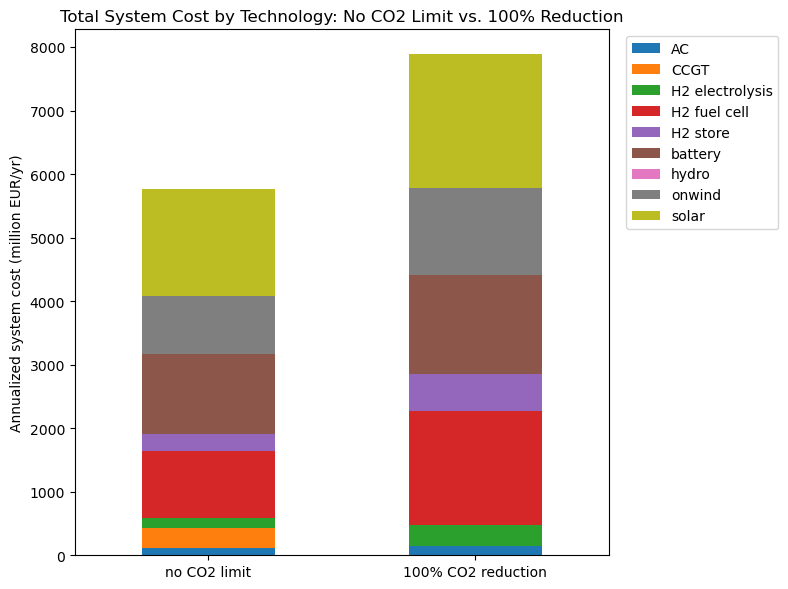

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
(cost_table.T / 1e6).plot.bar(stacked=True, ax=ax)
ax.set_ylabel("Annualized system cost (million EUR/yr)")
ax.set_title("Total System Cost by Technology: No CO2 Limit vs. 100% Reduction")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)

fig.tight_layout()
savefig(fig, "pypsa/co2_comparison", "cost_by_technology.png")
plt.show()

## 2. Capacities Built per Technology

Same convention as the sensitivity analysis: H2 electrolysis (a load, not a source) is
excluded from the demand-covering power capacity chart and shown separately in its own H2
system subsection, alongside the fuel cell (supply) and store (energy).

In [ ]:
capacity_table = pd.DataFrame(
    {label: capacity_by_technology(net) for label, net in scenarios.items()}
).fillna(0)
capacity_table.index.name = "technology"

power_capacity_table = capacity_table.drop(index=["H2 store", "H2 electrolysis"], errors="ignore")
power_capacity_table

generation_table = pd.DataFrame(
    {label: generation_by_technology(net) for label, net in scenarios.items()}
).fillna(0)
generation_table.index.name = "technology"

power_capacity_table

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

power_capacity_table.T.plot.bar(stacked=True, ax=axes[0])
axes[0].set_ylabel("Optimal capacity (MW)")
axes[0].set_title("Demand-Covering Power Capacity")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
axes[0].tick_params(axis="x", rotation=0)

generation_table.reindex(power_capacity_table.index, fill_value=0).T.plot.bar(stacked=True, ax=axes[1])
axes[1].set_ylabel("Annual generation (MWh/yr)")
axes[1].set_title("Actual Generation by Technology")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=0)

fig.suptitle("No CO2 Limit vs. 100% Reduction")
fig.tight_layout()
savefig(fig, "pypsa/co2_comparison", "capacity_by_technology.png")
plt.show()

### H2 System: Electrolysis (Consumption), Fuel Cell (Supply), and Store (Energy)

In [7]:
h2_power_table = capacity_table.reindex(["H2 electrolysis", "H2 fuel cell"]).fillna(0)
h2_energy_table = capacity_table.loc[["H2 store"]] if "H2 store" in capacity_table.index else None

h2_power_table

,no CO2 limit,100% CO2 reduction
technology,,
H2 electrolysis,671.818876,1445.371871
H2 fuel cell,3705.438964,6341.175921


In [8]:
h2_energy_table

,no CO2 limit,100% CO2 reduction
technology,,
H2 store,1.435916e+06,3.071965e+06


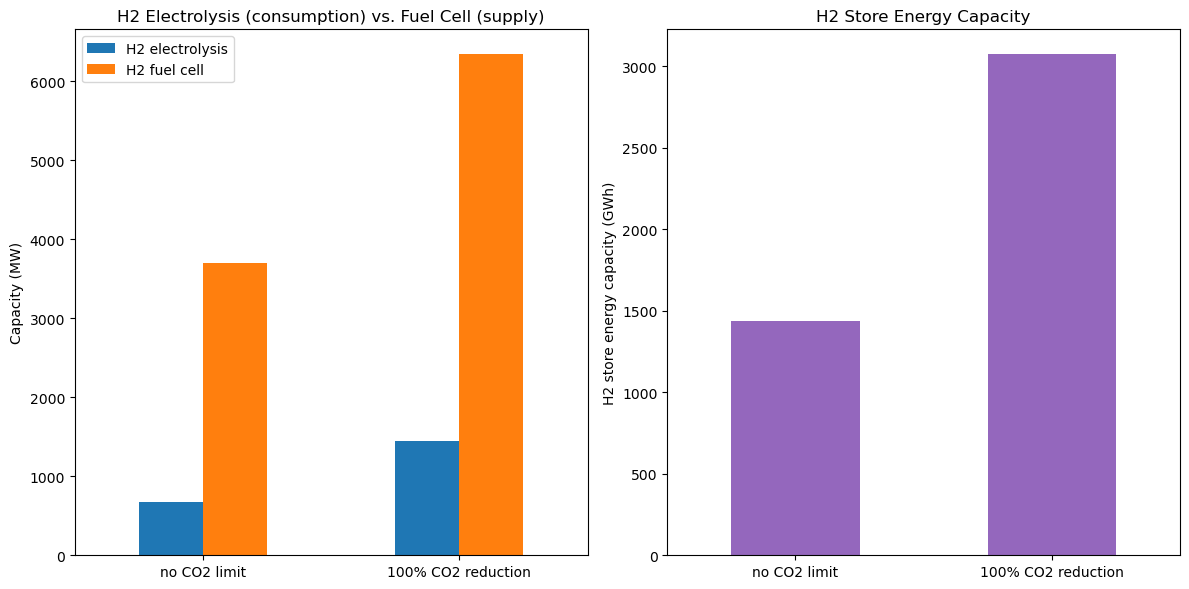

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

h2_power_table.T.plot.bar(ax=axes[0])
axes[0].set_ylabel("Capacity (MW)")
axes[0].set_title("H2 Electrolysis (consumption) vs. Fuel Cell (supply)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=0)

if h2_energy_table is not None:
    (h2_energy_table.T / 1e3).plot.bar(ax=axes[1], legend=False, color="tab:purple")
    axes[1].set_ylabel("H2 store energy capacity (GWh)")
    axes[1].set_title("H2 Store Energy Capacity")
    axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
savefig(fig, "pypsa/co2_comparison", "h2_system_capacity.png")
plt.show()

## 3. Electricity Mix

In [10]:
mix_table = pd.DataFrame(
    {label: electricity_mix(net) for label, net in scenarios.items()}
).fillna(0)
mix_table.index.name = "carrier"

mix_table

,no CO2 limit,100% CO2 reduction
carrier,,
CCGT,7.012267,0.000000
hydro,31.598030,28.987362
onwind,13.871342,15.630748
solar,47.518361,55.381891


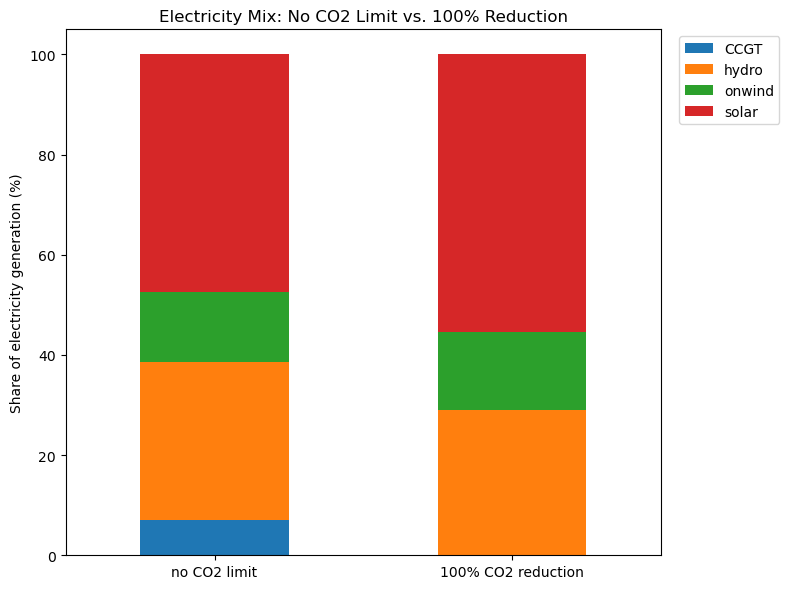

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
mix_table.T.plot.bar(stacked=True, ax=ax)
ax.set_ylabel("Share of electricity generation (%)")
ax.set_title("Electricity Mix: No CO2 Limit vs. 100% Reduction")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)

fig.tight_layout()
savefig(fig, "pypsa/co2_comparison", "electricity_mix.png")
plt.show()

## 4. CO2 Emissions and Shadow Price

Total emissions compare directly across both scenarios; the shadow price only exists for
the constrained (100% reduction) case, since "no CO2 limit" has no CO2 constraint to price.

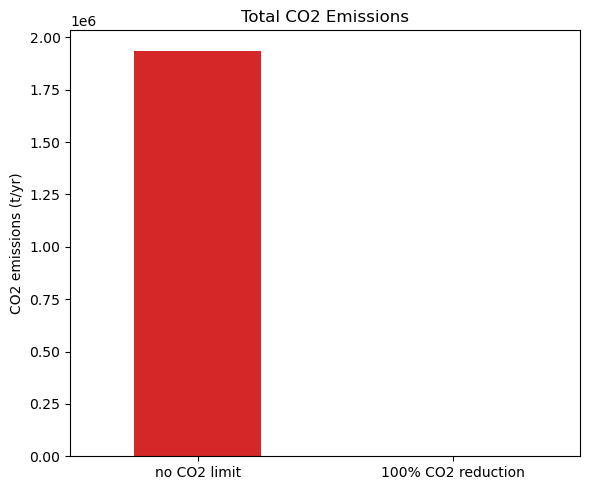

no CO2 limit          1.937021e+06
100% CO2 reduction    0.000000e+00
Name: total CO2 emissions (t/yr), dtype: float64

In [12]:
emissions = pd.Series({label: total_co2(net) for label, net in scenarios.items()}, name="total CO2 emissions (t/yr)")

fig, ax = plt.subplots(figsize=(6, 5))
emissions.plot.bar(ax=ax, color="tab:red")
ax.set_ylabel("CO2 emissions (t/yr)")
ax.set_title("Total CO2 Emissions")
plt.xticks(rotation=0)

fig.tight_layout()
savefig(fig, "pypsa/co2_comparison", "co2_emissions.png")
plt.show()
emissions

In [13]:
shadow_price = co2_shadow_price(scenarios["100% CO2 reduction"], cost_scale)
print(f"CO2 shadow price (100% reduction scenario): {shadow_price:,.0f} EUR/tCO2")
print("(no CO2 limit scenario has no CO2 constraint, so no shadow price applies)")

CO2 shadow price (100% reduction scenario): 16,268 EUR/tCO2
(no CO2 limit scenario has no CO2 constraint, so no shadow price applies)


## 5. Detailed Operation

Price Duration Curves

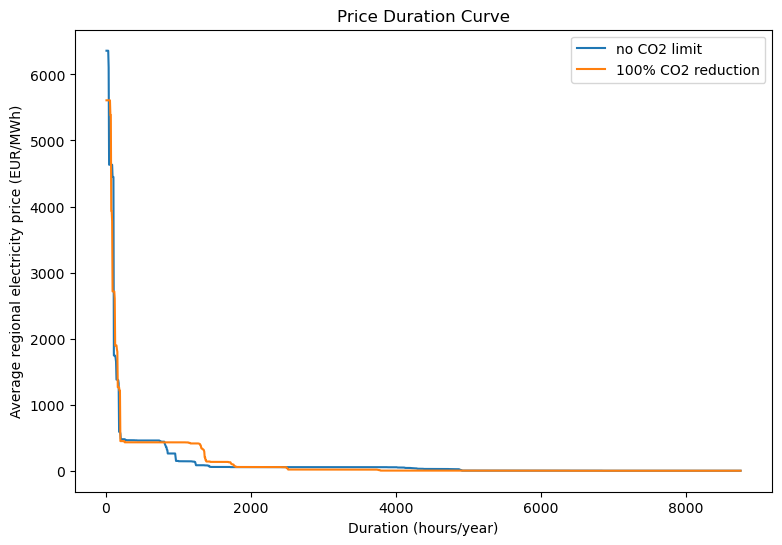

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))

for label, net in scenarios.items():
    elec_prices = net.buses_t.marginal_price[electricity_buses(net)] * cost_scale
    avg_price = elec_prices.mean(axis=1)
    weighting = net.snapshot_weightings.generators
    duration = weighting.cumsum().values

    sorted_price = avg_price.sort_values(ascending=False).values
    ax.plot(duration, sorted_price, label=label)

ax.set_xlabel("Duration (hours/year)")
ax.set_ylabel("Average regional electricity price (EUR/MWh)")
ax.set_title("Price Duration Curve")
ax.legend()

savefig(fig, "pypsa/co2_comparison", "price_duration_curve.png")
plt.show()

Average Electricity Price per Region

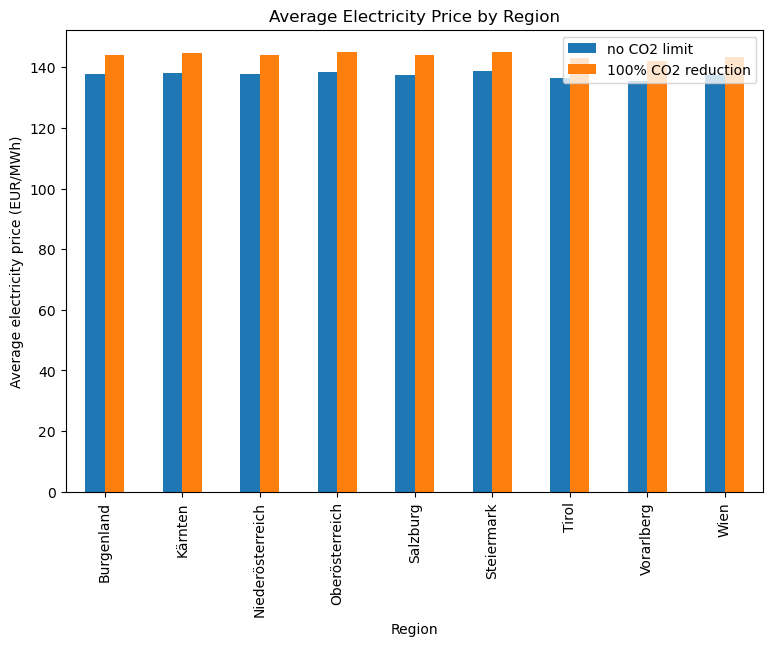

,no CO2 limit,100% CO2 reduction
name,,
Burgenland,137.807665,143.987171
Kärnten,138.161352,144.786006
Niederösterreich,137.747322,143.926828
Oberösterreich,138.504676,145.129331
Salzburg,137.549064,144.173719
Steiermark,138.866335,145.045841
Tirol,136.454879,143.079534
Vorarlberg,135.359804,141.984459
Wien,137.324548,143.504054


In [15]:
avg_regional_price = pd.DataFrame(
    {
        label: net.buses_t.marginal_price[electricity_buses(net)].mean() * cost_scale
        for label, net in scenarios.items()
    }
)

fig, ax = plt.subplots(figsize=(9, 6))
avg_regional_price.plot.bar(ax=ax)
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_xlabel("Region")
ax.set_title("Average Electricity Price by Region")

savefig(fig, "pypsa/co2_comparison", "average_regional_price.png")
plt.show()
avg_regional_price

Curtailment Rate (Wind and Solar)

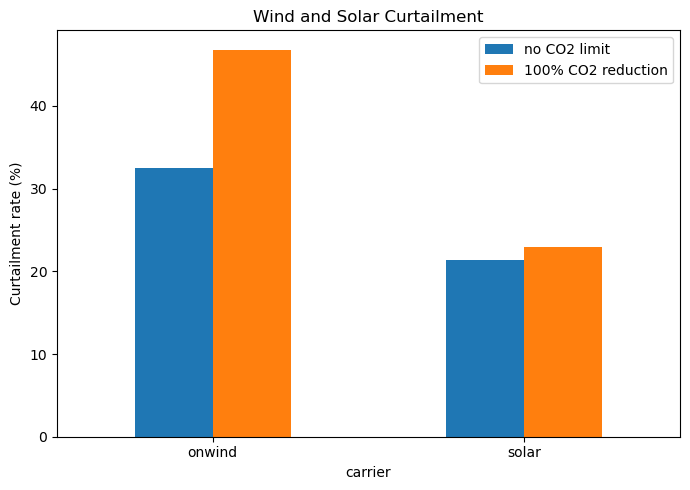

,no CO2 limit,100% CO2 reduction
carrier,,
onwind,32.465914,46.804622
solar,21.362673,22.969157


In [16]:
curtailment_table = pd.DataFrame(
    {label: curtailment_rate(net) for label, net in scenarios.items()}
)

fig, ax = plt.subplots(figsize=(7, 5))
curtailment_table.plot.bar(ax=ax)
ax.set_ylabel("Curtailment rate (%)")
ax.set_title("Wind and Solar Curtailment")
plt.xticks(rotation=0)

fig.tight_layout()
savefig(fig, "pypsa/co2_comparison", "curtailment_rate.png")
plt.show()
curtailment_table

Storage Filling Levels Throughout the Year

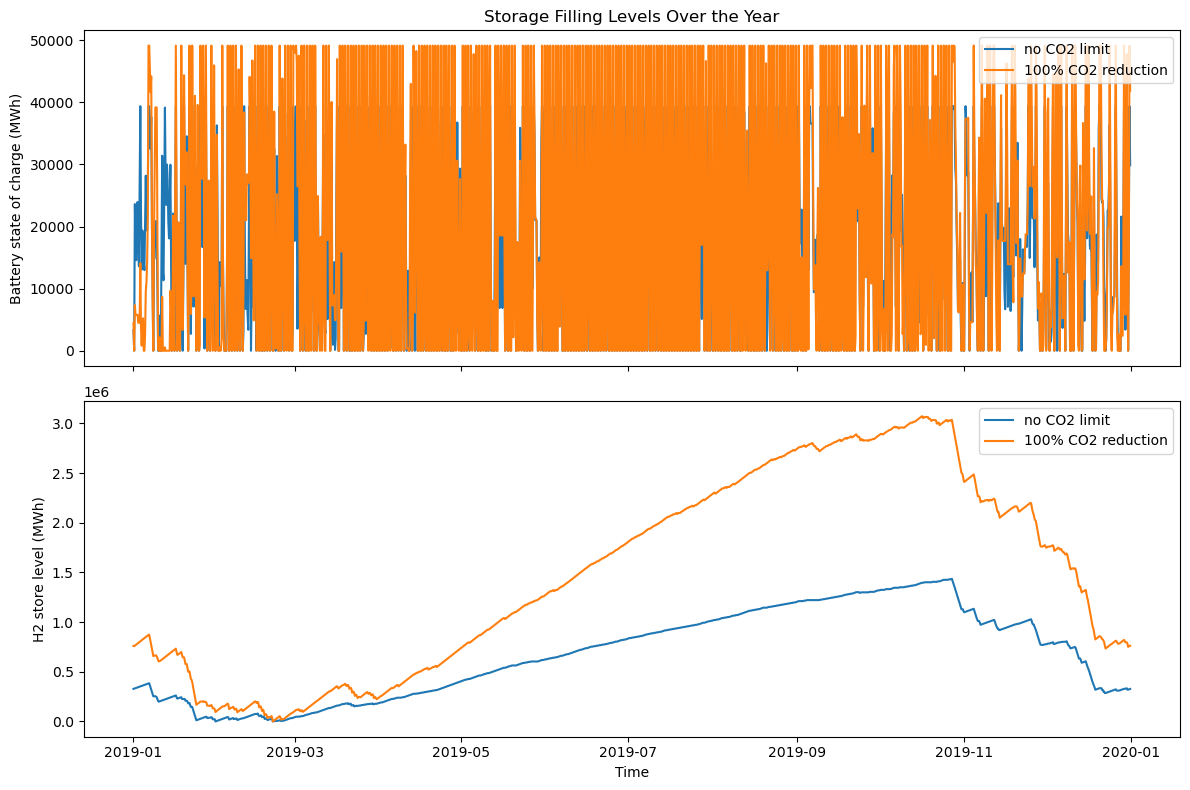

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for label, net in scenarios.items():
    battery_soc = net.storage_units_t.state_of_charge.sum(axis=1)
    h2_level = net.stores_t.e.sum(axis=1)
    axes[0].plot(battery_soc.index, battery_soc.values, label=label)
    axes[1].plot(h2_level.index, h2_level.values, label=label)

axes[0].set_ylabel("Battery state of charge (MWh)")
axes[0].set_title("Storage Filling Levels Over the Year")
axes[0].legend()
axes[1].set_ylabel("H2 store level (MWh)")
axes[1].set_xlabel("Time")
axes[1].legend()

fig.tight_layout()
savefig(fig, "pypsa/co2_comparison", "storage_filling_levels.png")
plt.show()

System Operation: Scarcity and Abundance Weeks

In [18]:
reference_net = next(iter(scenarios.values()))
vre_gens = reference_net.generators[reference_net.generators.carrier.isin(["onwind", "solar"])].index
combined_cf = reference_net.generators_t.p_max_pu[vre_gens].mean(axis=1)

weekly_cf = combined_cf.resample("7D").mean()
scarcity_week_start = weekly_cf.idxmin()
abundance_week_start = weekly_cf.idxmax()

print("scarcity week starting: ", scarcity_week_start, f"(avg VRE CF = {weekly_cf.min():.2%})")
print("abundance week starting:", abundance_week_start, f"(avg VRE CF = {weekly_cf.max():.2%})")

scarcity week starting:  2019-11-05 00:00:00 (avg VRE CF = 7.34%)
abundance week starting: 2019-04-23 00:00:00 (avg VRE CF = 20.02%)


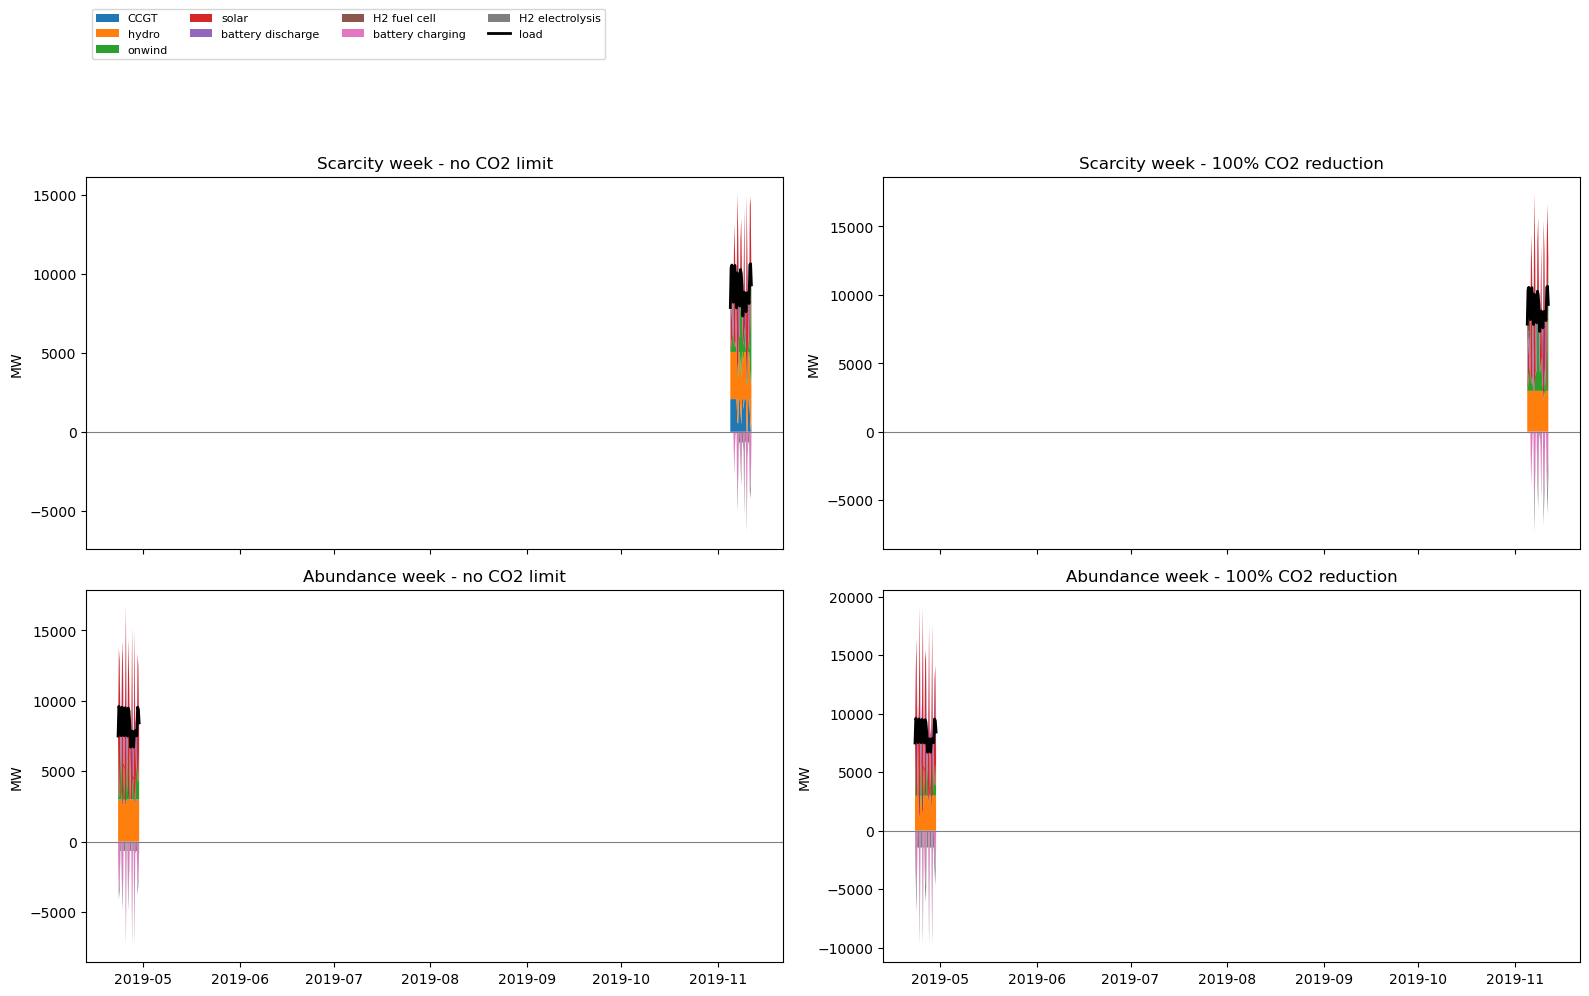

In [19]:
def plot_operation_week(network, week_start, title, ax):
    week_end = week_start + pd.Timedelta(days=7)
    snapshots = network.snapshots[(network.snapshots >= week_start) & (network.snapshots < week_end)]

    gen = network.generators_t.p.loc[snapshots].T.groupby(network.generators.carrier).sum().T

    battery_p = network.storage_units_t.p.loc[snapshots].sum(axis=1)
    battery_discharge = battery_p.clip(lower=0)
    battery_charge = battery_p.clip(upper=0)

    elec_links = network.links[network.links.carrier == "H2 electrolysis"].index
    fc_links = network.links[network.links.carrier == "H2 fuel cell"].index
    electrolysis_draw = network.links_t.p0.loc[snapshots, elec_links].sum(axis=1)  # positive = consumption
    fuel_cell_output = -network.links_t.p1.loc[snapshots, fc_links].sum(axis=1)  # positive = supply

    load = network.loads_t.p_set.loc[snapshots].sum(axis=1)

    positive_stack = pd.concat(
        [gen, battery_discharge.rename("battery discharge"), fuel_cell_output.rename("H2 fuel cell")],
        axis=1,
    ).clip(lower=0)
    negative_stack = pd.concat(
        [battery_charge.rename("battery charging"), (-electrolysis_draw).rename("H2 electrolysis")],
        axis=1,
    ).clip(upper=0)

    ax.stackplot(snapshots, positive_stack.T, labels=positive_stack.columns)
    ax.stackplot(snapshots, negative_stack.T, labels=negative_stack.columns)
    ax.plot(snapshots, load.values, color="black", linewidth=2, label="load")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("MW")


fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex="col")

for col, (label, net) in enumerate(scenarios.items()):
    plot_operation_week(net, scarcity_week_start, f"Scarcity week - {label}", axes[0, col])
    plot_operation_week(net, abundance_week_start, f"Abundance week - {label}", axes[1, col])

axes[0, 0].legend(bbox_to_anchor=(0, 1.3), loc="lower left", ncol=4, fontsize=8)
fig.tight_layout()
savefig(fig, "pypsa/co2_comparison", "operation_weeks.png")
plt.show()